# **Import Library**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# **Load Dataset**

In [3]:
df = pd.read_csv("Sales - Marketing customer dataset.csv")

In [4]:
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

In [6]:
df.describe()

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


# **EDA (Exploratory Data Analysis)**

In [7]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

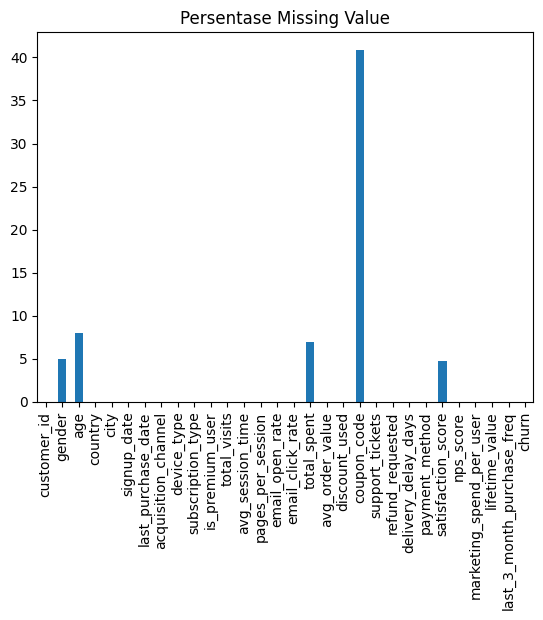

In [8]:
missing_percent.plot(kind='bar')
plt.title('Persentase Missing Value')
plt.show()

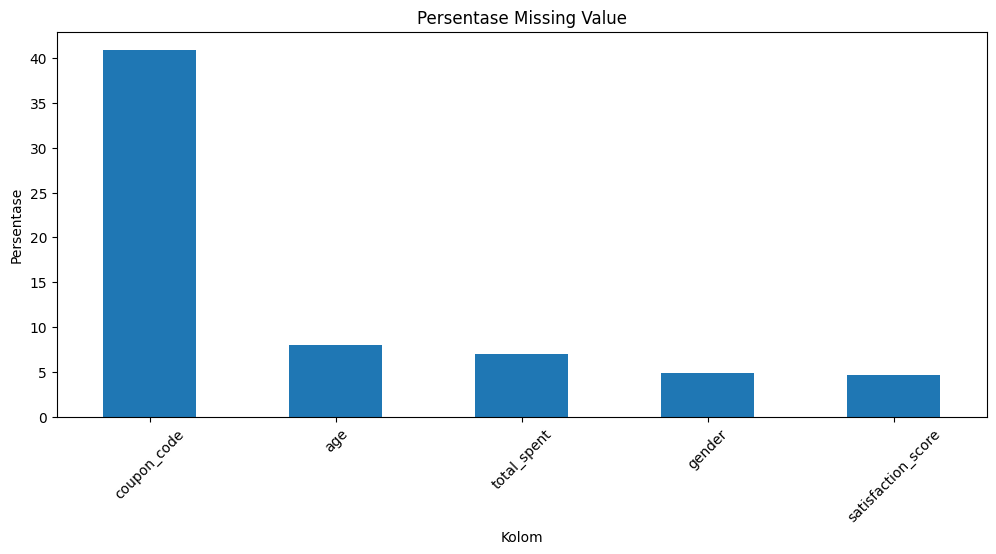

In [9]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent = missing_percent[missing_percent > 0]

if not missing_percent.empty:
    plt.figure(figsize=(12,5))

    missing_percent.sort_values(ascending=False).plot(
        kind='bar'
    )

    plt.title("Persentase Missing Value")
    plt.xlabel("Kolom")
    plt.ylabel("Persentase")

    plt.xticks(rotation=45)

    plt.show()
else:
    print("No missing values found in the dataset.")

# **DISTRIBUSI TARGET CHURN**

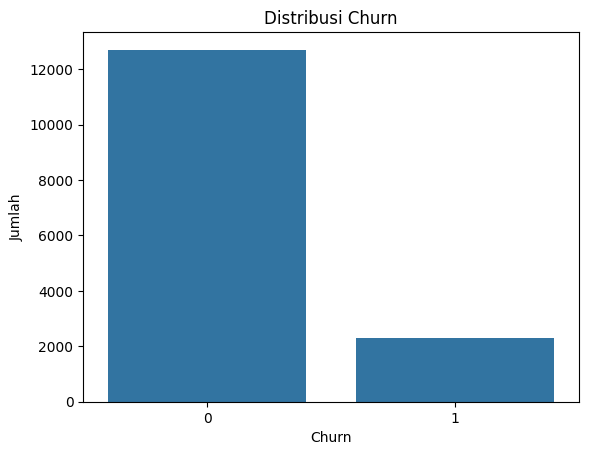

In [10]:
sns.countplot(x='churn', data=df)

plt.title("Distribusi Churn")
plt.xlabel("Churn")
plt.ylabel("Jumlah")
plt.show()

# **HEATMAP KORELASI**

In [11]:
numeric_df = df.select_dtypes(include=np.number)

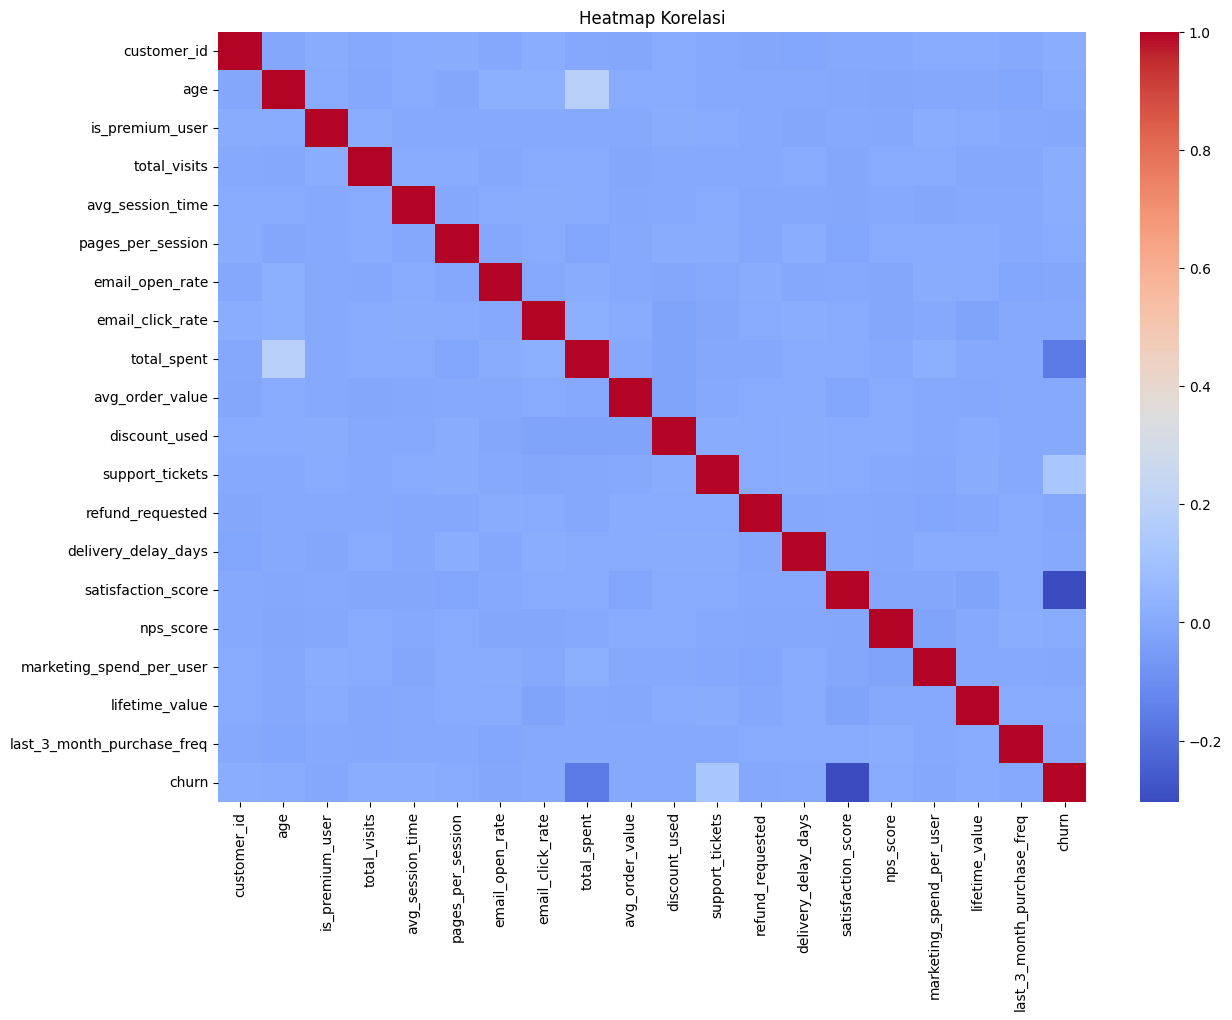

In [12]:
plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)

plt.title("Heatmap Korelasi")
plt.show()

# **DIRECT MODELING**

In [13]:
df_direct = df.copy()

df_direct = pd.get_dummies(df_direct, drop_first=True)

In [14]:
numeric_cols = df_direct.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df_direct[col] = df_direct[col].fillna(
        df_direct[col].median()
    )

In [15]:
X = df_direct.drop('churn', axis=1)
y = df_direct['churn']

# **TRAIN TEST SPLIT**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **MODEL SELECTION**

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier

In [18]:
lr = LogisticRegression(max_iter=1000)

rf = RandomForestClassifier()

knn = KNeighborsClassifier()

dt = DecisionTreeClassifier()

In [19]:
voting = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('knn', knn),
        ('dt', dt)
    ],
    voting='soft'
)

# **TRAINING DIRECT MODELING**

In [20]:
models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'Voting Classifier': voting
}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Model :", name)

    print("Accuracy :", accuracy_score(y_test, y_pred))

    print("Precision :", precision_score(y_test, y_pred))

    print("Recall :", recall_score(y_test, y_pred))

    print("F1-Score :", f1_score(y_test, y_pred))

    print()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model : Logistic Regression
Accuracy : 0.8506666666666667
Precision : 0.4863013698630137
Recall : 0.15990990990990991
F1-Score : 0.24067796610169492

Model : Random Forest
Accuracy : 0.855
Precision : 0.5569620253164557
Recall : 0.0990990990990991
F1-Score : 0.1682600382409178



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model : Voting Classifier
Accuracy : 0.8553333333333333
Precision : 0.5201612903225806
Recall : 0.2905405405405405
F1-Score : 0.37283236994219654



# **CONFUSION MATRIX**

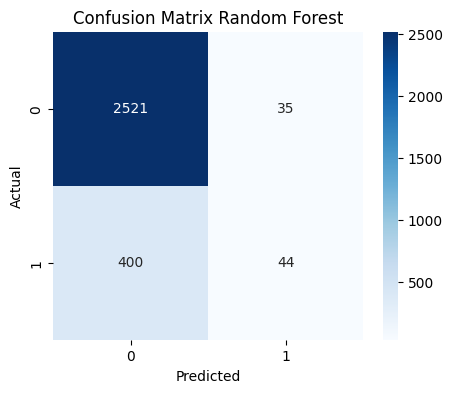

In [21]:
y_pred_rf = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [22]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92      2556
           1       0.56      0.10      0.17       444

    accuracy                           0.85      3000
   macro avg       0.71      0.54      0.54      3000
weighted avg       0.82      0.85      0.81      3000



# **MODELING DENGAN PREPROCESSING**

In [23]:
df_prep = df.copy()

# **HANDLING MISSING VALUE**

In [24]:
numeric_cols = df_prep.select_dtypes(include=np.number).columns

for col in numeric_cols:

    if col != 'churn':

        df_prep[col] = df_prep[col].fillna(
            df_prep[col].median()
        )

In [25]:
categorical_cols = df_prep.select_dtypes(include='object').columns

for col in categorical_cols:

    df_prep[col] = df_prep[col].fillna(
        df_prep[col].mode()[0]
    )

In [26]:
df_prep = df_prep.drop_duplicates()

In [27]:
numeric_cols = df_prep.select_dtypes(include=np.number).columns.drop('churn')

for col in numeric_cols:

    Q1 = df_prep[col].quantile(0.25)

    Q3 = df_prep[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR

    upper_bound = Q3 + 1.5 * IQR

    df_prep[col] = np.where(
        df_prep[col] < lower_bound,
        lower_bound,
        df_prep[col]
    )

    df_prep[col] = np.where(
        df_prep[col] > upper_bound,
        upper_bound,
        df_prep[col]
    )

# **ENCODING**

In [28]:
df_prep = pd.get_dummies(
    df_prep,
    drop_first=True
)

In [29]:
X = df_prep.drop('churn', axis=1)

y = df_prep['churn']

In [30]:
print(X.shape)

print(y.shape)

(15000, 1842)
(15000,)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **SCALING**

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# **TRAINING MODEL WITH PREPROCESSING**

In [33]:
models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'Voting Classifier': voting
}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    print("Model :", name)

    print("Accuracy :", accuracy_score(y_test, y_pred))

    print("Precision :", precision_score(y_test, y_pred))

    print("Recall :", recall_score(y_test, y_pred))

    print("F1-Score :", f1_score(y_test, y_pred))

    print()

Model : Logistic Regression
Accuracy : 0.8256666666666667
Precision : 0.382089552238806
Recall : 0.2882882882882883
F1-Score : 0.3286264441591784

Model : Random Forest
Accuracy : 0.8526666666666667
Precision : 0.5121951219512195
Recall : 0.0945945945945946
F1-Score : 0.1596958174904943

Model : Voting Classifier
Accuracy : 0.8546666666666667
Precision : 0.5222222222222223
Recall : 0.21171171171171171
F1-Score : 0.30128205128205127



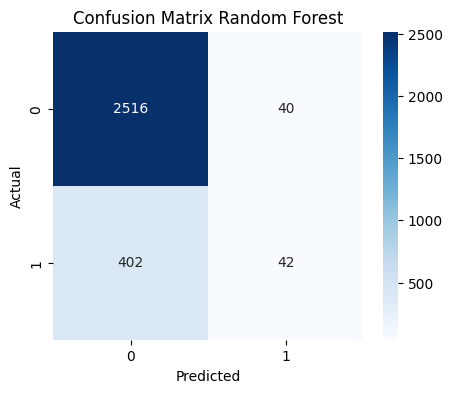

In [34]:
y_pred_rf = rf.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# **HYPERPARAMETER TUNING DAN FEATURE SELECTION**

In [35]:
rf.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
8,total_spent,0.144319
14,satisfaction_score,0.120303
11,support_tickets,0.049356
0,customer_id,0.025596
4,avg_session_time,0.025088
16,marketing_spend_per_user,0.024267
17,lifetime_value,0.023967
9,avg_order_value,0.023644
5,pages_per_session,0.023613
6,email_open_rate,0.022322


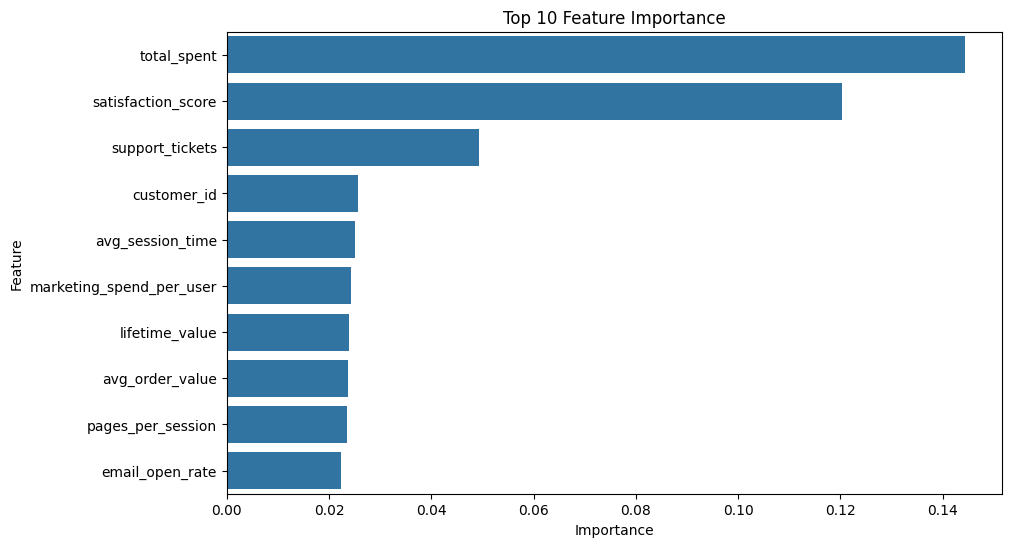

In [36]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title('Top 10 Feature Importance')

plt.show()

In [37]:
param_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}

In [38]:
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

In [39]:
from sklearn.model_selection import GridSearchCV

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_lr,
    cv=5,
    scoring='f1'
)

grid_lr.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear']},
             scoring='f1')

In [40]:
grid_rf = GridSearchCV(
    RandomForestClassifier(),
    param_rf,
    cv=5,
    scoring='f1'
)

grid_rf.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [41]:
print("Best LR Parameter")
print(grid_lr.best_params_)

print("Best RF Parameter")
print(grid_rf.best_params_)

Best LR Parameter
{'C': 0.1, 'solver': 'liblinear'}
Best RF Parameter
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [42]:
best_lr = grid_lr.best_estimator_

best_rf = grid_rf.best_estimator_

In [43]:
best_rf.fit(X_train_scaled, y_train)

y_pred_best = best_rf.predict(X_test_scaled)

In [44]:
print("Accuracy :", accuracy_score(y_test, y_pred_best))

print("Precision :", precision_score(y_test, y_pred_best))

print("Recall :", recall_score(y_test, y_pred_best))

print("F1 Score :", f1_score(y_test, y_pred_best))

Accuracy : 0.8516666666666667
Precision : 0.4897959183673469
Recall : 0.05405405405405406
F1 Score : 0.0973630831643002


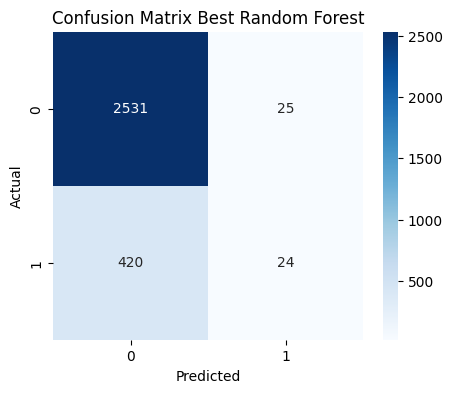

In [45]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix Best Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()